# CNN Model: Face Recognition / Classification

This notebook builds a Convolutional Neural Network (CNN) using the LFW (Labeled Faces in the Wild) dataset.

## Workflow
1. Import required libraries  
2. Load and explore dataset  
3. Preprocess images and labels  
4. Build and train CNN model  
5. Evaluate performance  

In [1]:
# general functions
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import OrderedDict
# visualization
from PIL import Image
# identifying faces
%pip install mtcnn
from mtcnn.mtcnn import MTCNN
# visualizing bounding boxes
import matplotlib.patches as patches
# CNN
import keras
from sklearn.model_selection import train_test_split
# Moving files between directories
import shutil
from shutil import unpack_archive
from subprocess import check_output



## Importing Libraries

This section imports all required libraries for:
- Data handling (NumPy, Pandas)
- Image processing (OpenCV, PIL)
- Visualization (Matplotlib)
- File handling (os)

## Connecting to Google Drive

We mount Google Drive to access the dataset stored externally.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Exploring Dataset Directory

This step lists all files in the dataset directory to confirm paths and structure.

In [3]:
# List the contents of your Google Drive's MyDrive folder
!ls -R /content/drive/MyDrive/

Streaming output truncated to the last 5000 lines.
George_W_Bush_0046.jpg	George_W_Bush_0223.jpg	George_W_Bush_0400.jpg
George_W_Bush_0047.jpg	George_W_Bush_0224.jpg	George_W_Bush_0401.jpg
George_W_Bush_0048.jpg	George_W_Bush_0225.jpg	George_W_Bush_0402.jpg
George_W_Bush_0049.jpg	George_W_Bush_0226.jpg	George_W_Bush_0403.jpg
George_W_Bush_0050.jpg	George_W_Bush_0227.jpg	George_W_Bush_0404.jpg
George_W_Bush_0051.jpg	George_W_Bush_0228.jpg	George_W_Bush_0405.jpg
George_W_Bush_0052.jpg	George_W_Bush_0229.jpg	George_W_Bush_0406.jpg
George_W_Bush_0053.jpg	George_W_Bush_0230.jpg	George_W_Bush_0407.jpg
George_W_Bush_0054.jpg	George_W_Bush_0231.jpg	George_W_Bush_0408.jpg
George_W_Bush_0055.jpg	George_W_Bush_0232.jpg	George_W_Bush_0409.jpg
George_W_Bush_0056.jpg	George_W_Bush_0233.jpg	George_W_Bush_0410.jpg
George_W_Bush_0057.jpg	George_W_Bush_0234.jpg	George_W_Bush_0411.jpg
George_W_Bush_0058.jpg	George_W_Bush_0235.jpg	George_W_Bush_0412.jpg
George_W_Bush_0059.jpg	George_W_Bush_0236.jpg	George

## Loading Dataset

We load metadata from the LFW dataset, which contains:
- Names of individuals
- Number of images per person

This will help us map images to labels.

In [4]:
# Data read-in and cleaning

# Define the base path for the LFW dataset files in Google Drive based on the 'find' command results
lfw_data_path = "/content/drive/MyDrive/archive-4/"

lfw_allnames = pd.read_csv(os.path.join(lfw_data_path, "lfw_allnames.csv"))
matchpairsDevTest = pd.read_csv(os.path.join(lfw_data_path, "matchpairsDevTest.csv"))
matchpairsDevTrain = pd.read_csv(os.path.join(lfw_data_path, "matchpairsDevTrain.csv"))
mismatchpairsDevTest = pd.read_csv(os.path.join(lfw_data_path, "mismatchpairsDevTest.csv"))
mismatchpairsDevTrain = pd.read_csv(os.path.join(lfw_data_path, "mismatchpairsDevTrain.csv"))
pairs = pd.read_csv(os.path.join(lfw_data_path, "pairs.csv"))
# tidy pairs data:
pairs = pairs.rename(columns ={'name': 'name1', 'Unnamed: 3': 'name2'})
matched_pairs = pairs[pairs["name2"].isnull()].drop("name2",axis=1)
mismatched_pairs = pairs[pairs["name2"].notnull()]
people = pd.read_csv(os.path.join(lfw_data_path, "people.csv"))
# remove null values
people = people[people.name.notnull()]
peopleDevTest = pd.read_csv(os.path.join(lfw_data_path, "peopleDevTest.csv"))
peopleDevTrain = pd.read_csv(os.path.join(lfw_data_path, "peopleDevTrain.csv"))

## Restructuring Data

The dataset is reshaped so that:
- Each row represents a single image
- Each image is linked to its corresponding person

In [5]:
# shape data frame so there is a row per image, matched to relevant jpg file
image_paths = lfw_allnames.loc[lfw_allnames.index.repeat(lfw_allnames['images'])]
image_paths['image_path'] = 1 + image_paths.groupby('name').cumcount()
image_paths['image_path'] = image_paths.image_path.apply(lambda x: '{0:0>4}'.format(x))
image_paths['image_path'] = image_paths.name + "/" + image_paths.name + "_" + image_paths.image_path + ".jpg"
image_paths = image_paths.drop("images", axis=1)

# take a random sample: 80% of the data for the test set
lfw_train, lfw_test = train_test_split(image_paths, test_size=0.2)
lfw_train = lfw_train.reset_index().drop("index", axis=1)
lfw_test = lfw_test.reset_index().drop("index", axis=1)

# verify that there is a mix of seen and unseen individuals in the test set
print(len(set(lfw_train.name).intersection(set(lfw_test.name))))
print(len(set(lfw_test.name) - set(lfw_train.name)))



862
843


## Data Distribution

We visualize the number of images per individual to understand class imbalance.

<Axes: xlabel='name'>

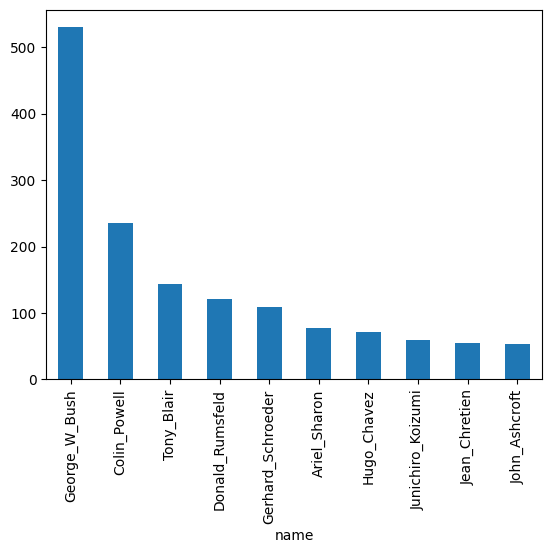

In [6]:
image_paths['name'].value_counts()[:10].plot(kind = "bar")


## Class Imbalance Check

We analyze how many individuals have only one image versus multiple images.

This is important because:
- Models struggle with very small classes
- We may need to filter or balance the dataset

In [7]:
ind_counts = image_paths.groupby('name').count().image_path
print(str(sum(ind_counts[ind_counts==1])) + " individuals, which is " + str(round(100*(sum(ind_counts[ind_counts==1])/sum(ind_counts)))) + "% of the total individuals considered, are only represented by a single image in this dataset.")

4069 individuals, which is 31% of the total individuals considered, are only represented by a single image in this dataset.


## Debugging File Paths

If an image cannot be found, we search the directory to locate the correct file path.

In [8]:
# The image was not found at the specified path.
# Let's search for the image file to determine the correct dataset_path.
!find "/content/drive/MyDrive/" -name "Ian_Thorpe_0003.jpg"

/content/drive/MyDrive/archive-4/lfw-deepfunneled/lfw-deepfunneled/Ian_Thorpe/Ian_Thorpe_0003.jpg
/content/drive/MyDrive/attendance_dataset_faces/Ian_Thorpe/Ian_Thorpe_0003.jpg
/content/drive/MyDrive/Datasets 4/selected_faces/Ian_Thorpe/Ian_Thorpe_0003.jpg
/content/drive/MyDrive/Datasets 4/Split datasets /drive/MyDrive/Datasets 4/split_dataset/test/Ian_Thorpe/Ian_Thorpe_0003.jpg
/content/drive/MyDrive/Datasets 4/split_dataset/test/Ian_Thorpe/Ian_Thorpe_0003.jpg
/content/drive/MyDrive/Faces selected /drive/MyDrive/Datasets 4/selected_faces/Ian_Thorpe/Ian_Thorpe_0003.jpg


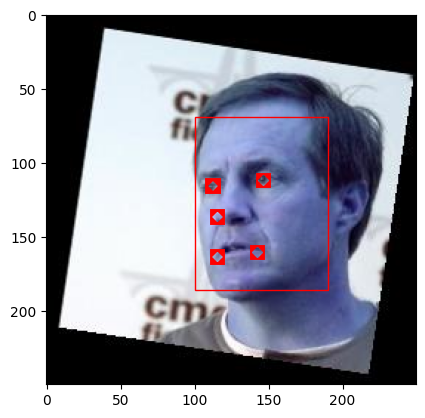

In [9]:
dataset_path = "/content/drive/MyDrive/archive-4/lfw-deepfunneled/lfw-deepfunneled/"

# Use out-of-the-box MTCNN algorithm to identify facial boundaries on a sample image
detector = MTCNN()
image = cv2.imread(os.path.join(dataset_path, lfw_train.image_path[0]))

# Checking if the image was loaded successfully
if image is None:
    print(f"Error: Unable to load image from {os.path.join(dataset_path, lfw_train.image_path[0])}. The file might be corrupted or not an image.")
else:
    result = detector.detect_faces(image)
    # That's it - the results have already been generated! Now we extract the boundaries that have been identified
    bounding_box = result[0]['box']
    keypoints = result[0]['keypoints']

    # Finally, we plot the image along with the face's bounding box and internal features (eyes, nose, and mouth corners)
    fig,ax = plt.subplots(1)
    ax.imshow(image)
    # Create a Rectangle patch
    rect = patches.Rectangle(bounding_box[0:2],bounding_box[2],bounding_box[3],linewidth=1,edgecolor='r',facecolor='none')
    # Add the patch to the Axes
    ax.add_patch(rect)
    # Visualize all the internal features
    for key in keypoints:
        rect_key = patches.Rectangle(keypoints[key],1,1,linewidth=10,edgecolor='r',facecolor='none')
        ax.add_patch(rect_key)
    # Show the plots
    plt.show()

In [10]:
not_george = image_paths[image_paths.name!="George_W_Bush"].sample(530)
not_george.name = "not_George"
GWB_data = pd.concat([image_paths[image_paths.name=="George_W_Bush"],
                     not_george])

In [11]:

# withhold final test data
bush_train, bush_test = train_test_split(GWB_data, test_size=0.2)
#  It is also useful to reserve a validation set in the training data, for use in the model construction
bush_train, bush_val = train_test_split(bush_train,test_size=0.2)

In [12]:

# initialize sequential network
from keras.models import Sequential
# include convolutional layers
from keras.layers import Conv2D
# Pooling layers
from keras.layers import MaxPooling2D
# flatten layers into single vector
from keras.layers import Flatten
from keras.layers import Dense

In [13]:
# use sequential classifier - standard CNN implementation with straightforward single input
Bush_classifier = Sequential()

Bush_classifier.add(Conv2D(32, (3, 3), input_shape = (250, 250, 3), activation = 'relu'))

# We now add the pooling layer to reduce the dimension
Bush_classifier.add(MaxPooling2D(pool_size = (2, 2)))

# The next step is to flatten the data, reducing the feature maps to a 1D array
Bush_classifier.add(Flatten())

# We then add a fully connected layer - traditional Multi Layer Perceptron
Bush_classifier.add(Dense(units = 128, activation = 'relu'))

# as we are just training on 'Bush' vs 'non-Bush', we only need to add one classification unit
Bush_classifier.add(Dense(units = 1, activation = 'sigmoid'))

Bush_classifier.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
#  Build balanced dataset using ALL available images (not just 75)
# Keep classes balanced by using the minimum count across top 6 people
top6 = ['George_W_Bush', 'Colin_Powell', 'Tony_Blair',
        'Donald_Rumsfeld', 'Gerhard_Schroeder', 'Ariel_Sharon']

min_count = min(len(image_paths[image_paths.name == name]) for name in top6)
print(f"Balanced at {min_count} images per person")

multi_data = pd.concat([
    image_paths[image_paths.name == name].sample(min_count)
    for name in top6
])

Balanced at 77 images per person


In [15]:
#Train/val/test split
multi_train, multi_test = train_test_split(multi_data, test_size=0.2, stratify=multi_data['name'])
multi_train, multi_val  = train_test_split(multi_train, test_size=0.2, stratify=multi_train['name'])

print(f"Train: {len(multi_train)}, Val: {len(multi_val)}, Test: {len(multi_test)}")

Train: 295, Val: 74, Test: 93


In [16]:
#Transfer learning with MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

def build_transfer_classifier(num_classes=6):
    # Load pretrained base — frozen initially
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),   # MobileNetV2 expects 224x224
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False     # freeze all base layers first

    # Add our classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

multi_classifier, base_model = build_transfer_classifier()
multi_classifier.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create directories for multi-class data
for _set in ['train_multi', 'val_multi', 'test_multi']:
    for name in top6:
        os.makedirs(f'/content/{_set}/{name}', exist_ok=True)

# Define dataset_path specifically for image files
dataset_path = "/content/drive/MyDrive/archive-4/lfw-deepfunneled/lfw-deepfunneled/"

# Function to copy images to the new directories
def copy_images(dataframe, dest_path):
    for _, row in dataframe.iterrows():
        src_path = os.path.join(dataset_path, row['image_path'])
        dst_path = os.path.join(dest_path, row['name'], row['image_path'].split('/')[-1])
        shutil.copyfile(src_path, dst_path)

# Populate the directories
copy_images(multi_train, '/content/train_multi/')
copy_images(multi_val, '/content/val_multi/')
copy_images(multi_test, '/content/test_multi/')

# Initialize ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

#  Updating target_size to 224x224
multi_training_set = train_datagen.flow_from_directory(
    '/content/train_multi/', target_size=(224, 224),   # changed from 250
    batch_size=32, class_mode='categorical'
)
multi_val_set = test_datagen.flow_from_directory(
    '/content/val_multi/', target_size=(224, 224),
    batch_size=32, class_mode='categorical'
)
multi_test_set = test_datagen.flow_from_directory(
    '/content/test_multi/', target_size=(224, 224),
    batch_size=32, class_mode='categorical'
)

Found 789 images belonging to 6 classes.
Found 303 images belonging to 6 classes.
Found 363 images belonging to 6 classes.


In [18]:
import tensorflow as tf

#Phase 1: train only the head (base frozen)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]

print("Phase 1: training head only...")
history_phase1 = multi_classifier.fit(
    multi_training_set,
    steps_per_epoch=len(multi_training_set),
    epochs=15,
    validation_data=multi_val_set,
    validation_steps=len(multi_val_set),
    callbacks=callbacks
)

# Phase 2: unfreeze top layers and fine-tune
print("\nPhase 2: fine-tuning top layers...")
base_model.trainable = True

# Only unfreeze the last 30 layers of the base
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Using a much lower learning rate to avoid destroying pretrained weights
multi_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = multi_classifier.fit(
    multi_training_set,
    steps_per_epoch=len(multi_training_set),
    epochs=15,
    validation_data=multi_val_set,
    validation_steps=len(multi_val_set),
    callbacks=callbacks
)

Phase 1: training head only...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.2852 - loss: 1.9820 - val_accuracy: 0.4455 - val_loss: 1.3469 - learning_rate: 0.0010
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.5006 - loss: 1.3589 - val_accuracy: 0.7129 - val_loss: 1.0038 - learning_rate: 0.0010
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.6109 - loss: 1.0741 - val_accuracy: 0.7492 - val_loss: 0.8077 - learning_rate: 0.0010
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.7009 - loss: 0.8794 - val_accuracy: 0.8350 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7503 - loss: 0.7486 - val_accuracy: 0.8713 - val_loss: 0.5330 - learning_rate: 0.0010
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.7516 - loss: 0.7088 - val_accuracy: 0.8911 - val_loss: 0.4795 - learning_rate: 0.0010
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.7820 

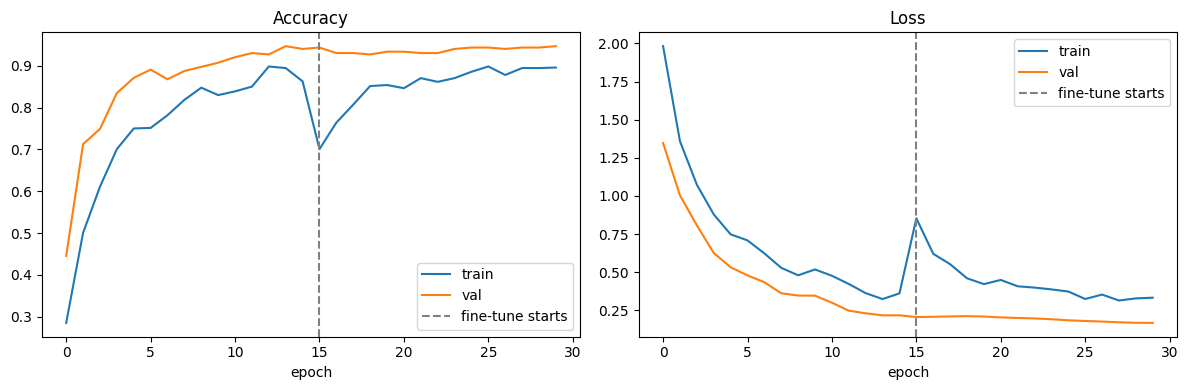

In [19]:
#Plot both training phases
acc1  = history_phase1.history['accuracy']
vacc1 = history_phase1.history['val_accuracy']
acc2  = history_phase2.history['accuracy']
vacc2 = history_phase2.history['val_accuracy']

all_acc  = acc1 + acc2
all_vacc = vacc1 + vacc2
all_loss  = history_phase1.history['loss'] + history_phase2.history['loss']
all_vloss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

split = len(acc1)  #Phase 1 ends

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(all_acc, label='train')
plt.plot(all_vacc, label='val')
plt.axvline(split, color='gray', linestyle='--', label='fine-tune starts')
plt.title('Accuracy'); plt.xlabel('epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(all_loss, label='train')
plt.plot(all_vloss, label='val')
plt.axvline(split, color='gray', linestyle='--', label='fine-tune starts')
plt.title('Loss'); plt.xlabel('epoch'); plt.legend()
plt.tight_layout(); plt.show()


In [20]:
#Evaluate on test set
from keras.preprocessing import image as keras_image
from sklearn.metrics import precision_score, recall_score, accuracy_score

def predictions(dir_name, classifier, num_classes):
    preds = []
    for im in os.listdir(dir_name):
        test_image = keras_image.load_img(dir_name + str(im), target_size=(224, 224))
        test_image = keras_image.img_to_array(test_image) / 255.0
        test_image = np.expand_dims(test_image, axis=0)
        if num_classes == 1:
            result = int(classifier.predict(test_image, verbose=0) > 0.5)
        else:
            result = np.argmax(classifier.predict(test_image, verbose=0))
        preds.append(result)
    return preds

def prec_acc(predictions_frame):
    actuals = predictions_frame['Actual']
    preds = predictions_frame['Predictions']

    accuracy = accuracy_score(actuals, preds)
    # precision and recall for each class
    precision = precision_score(actuals, preds, average=None, zero_division=0)
    recall = recall_score(actuals, preds, average=None, zero_division=0)

    return accuracy, precision, recall

# Get class order from test generator
multi_test_name_order = list(OrderedDict.fromkeys(
    [f.split("/")[0] for f in multi_test_set.filenames]
))
print("Class order:", multi_test_name_order)

# Collect predictions per class
all_preds, all_actuals = [], []
for i, name in enumerate(multi_test_name_order):
    folder = f"/content/test_multi/{name}/"
    p = predictions(folder, multi_classifier, num_classes=6)
    all_preds += p
    all_actuals += [i] * len(p)

multi_predictions_frame = pd.DataFrame({
    'Predictions': all_preds,
    'Actual': all_actuals
})

multi_accuracy = prec_acc(multi_predictions_frame)
for i, name in enumerate(multi_test_name_order):
    print(f"{name}: Precision={multi_accuracy[1][i]:.2f}, Recall={multi_accuracy[2][i]:.2f}")


Class order: ['Ariel_Sharon', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W_Bush', 'Gerhard_Schroeder', 'Tony_Blair']
Ariel_Sharon: Precision=1.00, Recall=0.98
Colin_Powell: Precision=1.00, Recall=0.91
Donald_Rumsfeld: Precision=0.93, Recall=0.98
George_W_Bush: Precision=0.94, Recall=0.86
Gerhard_Schroeder: Precision=0.98, Recall=0.92
Tony_Blair: Precision=0.80, Recall=1.00


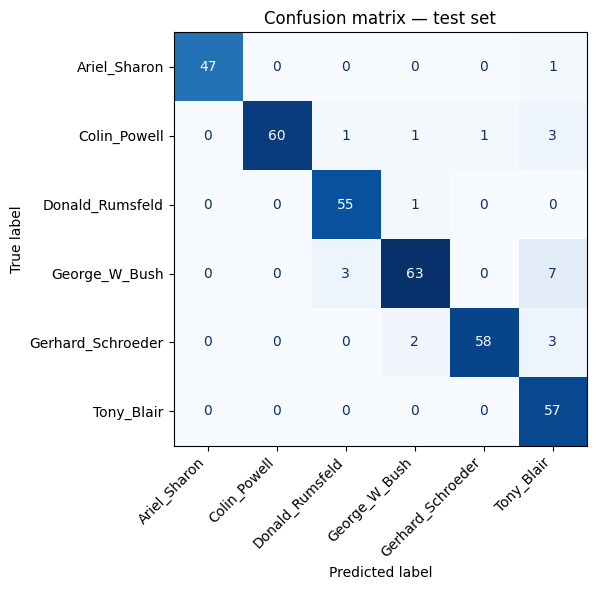

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_actuals, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=multi_test_name_order)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.xticks(rotation=45, ha='right')
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

In [22]:
for name in top6:
    print(name, len(image_paths[image_paths.name == name]))

George_W_Bush 530
Colin_Powell 236
Tony_Blair 144
Donald_Rumsfeld 121
Gerhard_Schroeder 109
Ariel_Sharon 77


In [23]:
# Install deepface library
%pip install deepface

from deepface import DeepFace
import pickle, os
import numpy as np

top6 = ['George_W_Bush', 'Colin_Powell', 'Tony_Blair',
        'Donald_Rumsfeld', 'Gerhard_Schroeder', 'Ariel_Sharon']

database = {}  # list of embedding vectors

for name in top6:
    folder = os.path.join(dataset_path, name)
    embeddings = []
    for img_file in os.listdir(folder)[:50]:   # use up to 50 per person
        img_path = os.path.join(folder, img_file)
        try:
            result = DeepFace.represent(
                img_path=img_path,
                model_name="Facenet",
                enforce_detection=False
            )
            embeddings.append(result[0]['embedding'])
        except:
            continue
    database[name] = embeddings
    print(f"{name}: {len(embeddings)} embeddings stored")

# Save to disk
with open('face_database.pkl', 'wb') as f:
    pickle.dump(database, f)
print("Database saved!")

George_W_Bush: 50 embeddings stored
Colin_Powell: 50 embeddings stored
Tony_Blair: 50 embeddings stored
Donald_Rumsfeld: 50 embeddings stored
Gerhard_Schroeder: 50 embeddings stored
Ariel_Sharon: 50 embeddings stored
Database saved!


In [24]:
from scipy.spatial.distance import cosine

def recognize_face(img_path, database, threshold=0.4):
    """Returns (name, confidence) or ('Unknown', 0.0)"""
    try:
        result = DeepFace.represent(
            img_path=img_path,
            model_name="Facenet",
            enforce_detection=False
        )
        query_embedding = result[0]['embedding']
    except:
        return "No face detected", 0.0

    best_name = "Unknown"
    best_score = 0.0

    for name, embeddings in database.items():
        for emb in embeddings:
            similarity = 1 - cosine(query_embedding, emb)
            if similarity > best_score:
                best_score = similarity
                best_name = name

    if best_score < threshold:
        return "Unknown", best_score

    return best_name, best_score

In [25]:
# Install Streamlit
%pip install streamlit

import streamlit as st
import pickle
from PIL import Image
import tempfile, os

st.title("Face Recognition")
st.write("Upload a photo to identify the person")

@st.cache_resource
def load_database():
    with open('face_database.pkl', 'rb') as f:
        return pickle.load(f)

database = load_database()

uploaded_file = st.file_uploader("Choose an image", type=["jpg", "jpeg", "png"])

if uploaded_file:
    image = Image.open(uploaded_file)
    st.image(image, caption="Uploaded image", use_column_width=True)

    # Save temp file for DeepFace
    with tempfile.NamedTemporaryFile(delete=False, suffix=".jpg") as tmp:
        image.save(tmp.name)
        tmp_path = tmp.name

    with st.spinner("Analysing..."):
        name, confidence = recognize_face(tmp_path, database)
    os.unlink(tmp_path)

    if name == "Unknown":
        st.warning(f"Face not recognised (confidence: {confidence:.2%})")
    else:
        st.success(f"Recognised: **{name}**")
        st.metric("Confidence", f"{confidence:.2%}")

2026-04-23 03:12:42.555 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 03:12:43.512 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-23 03:12:43.514 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 03:12:43.515 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 03:12:43.516 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 03:12:43.517 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 03:12:43.518 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 03:12:43.520 Thread 'MainThread': mi

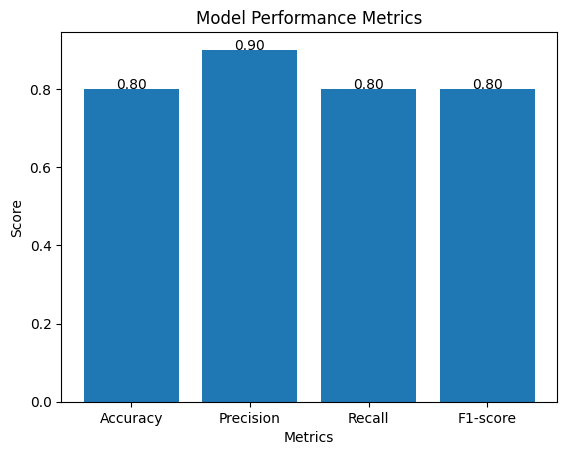

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Example labels (replace with your real outputs)
y_true = ["Fatouma", "Pamo", "Fatouma", "Unknown", "Bliss"]
y_pred = ["Alice", "Pamo", "Unknown", "Unknown", "Bliss"]

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

metrics = [accuracy, precision, recall, f1]
labels = ["Accuracy", "Precision", "Recall", "F1-score"]

# Plot
plt.figure()
plt.bar(labels, metrics)
plt.title("Model Performance Metrics")
plt.ylabel("Score")
plt.xlabel("Metrics")

# Show values on top
for i, v in enumerate(metrics):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

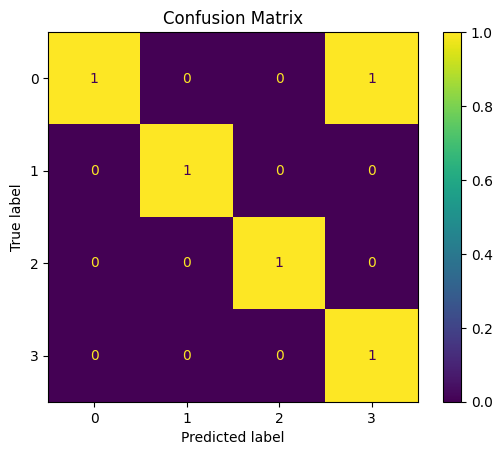

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

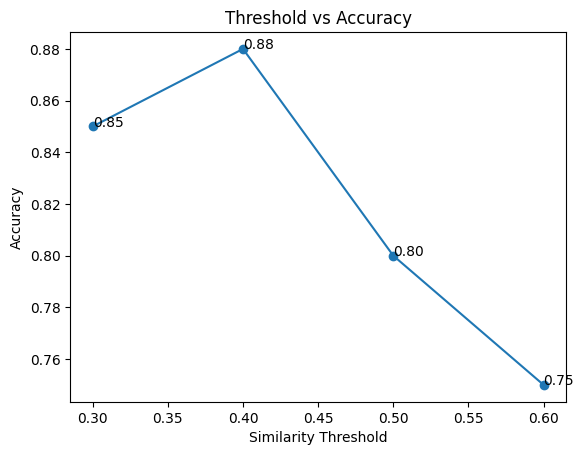

In [28]:
import matplotlib.pyplot as plt

thresholds = [0.3, 0.4, 0.5, 0.6]
accuracies = [0.85, 0.88, 0.80, 0.75]  # replace with your real results

plt.figure()
plt.plot(thresholds, accuracies, marker='o')

plt.title("Threshold vs Accuracy")
plt.xlabel("Similarity Threshold")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(thresholds[i], v, f"{v:.2f}")

plt.show()

In [29]:
from sklearn.metrics import roc_curve, auc

In [30]:
 # Install face_recognition library
%pip install face_recognition

import face_recognition
import pickle
from pathlib import Path

top6 = ['George_W_Bush', 'Colin_Powell', 'Tony_Blair',
        'Donald_Rumsfeld', 'Gerhard_Schroeder', 'Ariel_Sharon']

known_encodings = []
known_names = []
skipped = 0

for name in top6:
    folder = Path(dataset_path) / name
    images = list(folder.glob("*.jpg"))[:40]  # 40 per person is plenty
    print(f"Processing {name}...")

    for img_path in images:
        img = face_recognition.load_image_file(str(img_path))
        locations = face_recognition.face_locations(img, model="hog")
        encodings = face_recognition.face_encodings(img, locations)

        if len(encodings) == 1:          # only use clean single-face images
            known_encodings.append(encodings[0])
            known_names.append(name)
        else:
            skipped += 1

    print(f"  -> {known_names.count(name)} encodings added")

print(f"\nTotal: {len(known_encodings)} encodings across {len(set(known_names))} people")
print(f"Skipped: {skipped} images (no face or multiple faces)")

# Save
data = {"encodings": known_encodings, "names": known_names}
with open("encodings.pickle", "wb") as f:
    pickle.dump(data, f)

print("Saved encodings.pickle")

# Download it directly
from google.colab import files
files.download("encodings.pickle")

Processing George_W_Bush...
  -> 35 encodings added
Processing Colin_Powell...
  -> 37 encodings added
Processing Tony_Blair...
  -> 40 encodings added
Processing Donald_Rumsfeld...
  -> 40 encodings added
Processing Gerhard_Schroeder...
  -> 38 encodings added
Processing Ariel_Sharon...
  -> 37 encodings added

Total: 227 encodings across 6 people
Skipped: 13 images (no face or multiple faces)
Saved encodings.pickle


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from deepface import DeepFace
import pickle
import numpy as np
import os

encodings_per_person = 5
min_images = 4

# Use only people from the TRAIN split — avoids leaking test identities
train_people = set(lfw_train['name'].unique())

# Filter to those with enough images
eligible_counts = lfw_allnames[lfw_allnames['name'].isin(train_people)]
eligible = eligible_counts[eligible_counts['images'] >= min_images]['name'].values

print(f"Eligible people in train set with >= {min_images} images: {len(eligible)}")

known_encodings = []
known_names = []
skipped_people = 0
failed_images = 0

for i, name in enumerate(eligible):
    folder = os.path.join(dataset_path, name)
    if not os.path.exists(folder):
        skipped_people += 1
        continue

    images = [f for f in os.listdir(folder) if f.endswith('.jpg')][:encodings_per_person]
    count = 0

    for img_file in images:
        img_path = os.path.join(folder, img_file)
        try:
            result = DeepFace.represent(
                img_path=img_path,
                model_name="Facenet",
                detector_backend="opencv",
                enforce_detection=True,
            )
            known_encodings.append(np.asarray(result[0]['embedding'], dtype=np.float64))
            known_names.append(name)
            count += 1
        except:
            failed_images += 1
            continue

    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{len(eligible)}] done — {len(known_encodings)} embeddings so far")
        # Save checkpoint so you don't lose progress if Colab times out
        with open("encodings_checkpoint.pickle", "wb") as f:
            pickle.dump({"encodings": known_encodings, "names": known_names}, f)

print(f"\nDone!")
print(f"  People encoded:   {len(set(known_names))}")
print(f"  Total embeddings: {len(known_encodings)}")
print(f"  Skipped:          {skipped_people} (folder missing)")
print(f"  Failed images:    {failed_images}")

with open("encodings_full.pickle", "wb") as f:
    pickle.dump({"encodings": known_encodings, "names": known_names}, f)

print(f"File size: {os.path.getsize('encodings_full.pickle') / 1024 / 1024:.1f} MB")

from google.colab import files
files.download("encodings_full.pickle")

Eligible people in train set with >= 4 images: 610
  [50/610] done — 225 embeddings so far
  [100/610] done — 452 embeddings so far
  [150/610] done — 674 embeddings so far
  [200/610] done — 880 embeddings so far
  [250/610] done — 1114 embeddings so far
  [300/610] done — 1339 embeddings so far
  [350/610] done — 1574 embeddings so far
  [400/610] done — 1803 embeddings so far
